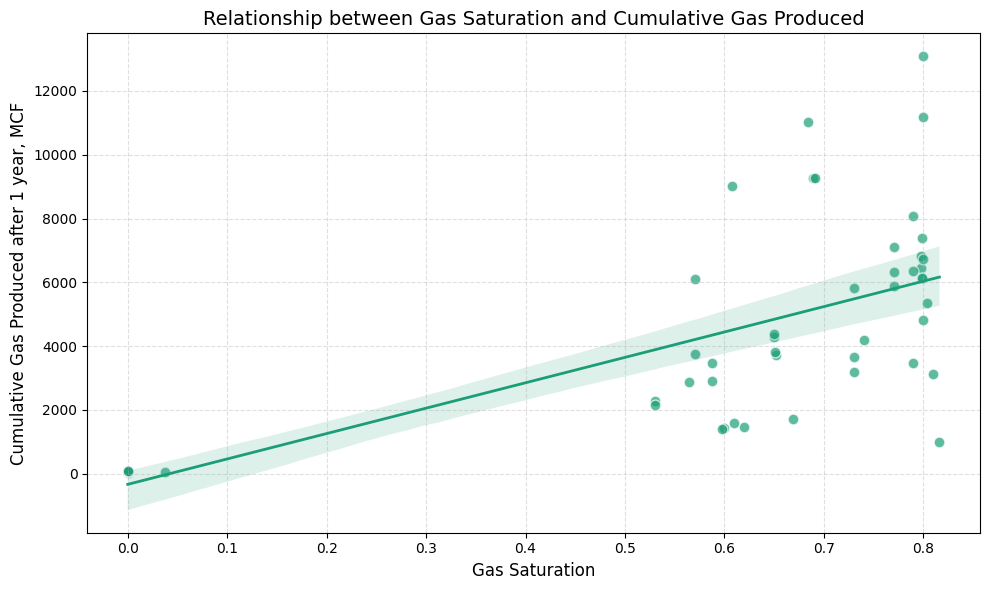

In [ ]:
# ============================================
# 12) Relación con la variable objetivo
#    y saturacion de Gas
# ============================================


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Import pandas to read the Excel file
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge
import xgboost as xgb

# Load the dataset if 'df' is not defined
# Assuming the Excel file is in the content directory
try:
    df
except NameError:
    print("DataFrame 'df' not found. Attempting to load 'SPE_shale_original - copia.xlsx'.")
    try:
        df = pd.read_excel('/content/SPE_shale_original - copia.xlsx')
        print("DataFrame 'df' loaded successfully.")
    except FileNotFoundError:
        print("Error: 'SPE_shale_original - copia.xlsx' not found. Please ensure the file is in '/content/'.")
        # Exit or handle the error appropriately if the file isn't found
    except Exception as e:
        print(f"An error occurred while loading the DataFrame: {e}")

# Clean up column names by stripping whitespace
df.columns = df.columns.str.strip()

TEAL = "#1b9e77"

plt.figure(figsize=(10, 6))
sns.regplot(
    x='Gas Saturation',
    y='Cumulative Gas Produced after 1 year, MCF',
    data=df,
    scatter_kws={'color': TEAL, 'alpha': 0.7, 's': 60, 'edgecolor': 'white'},
    line_kws={'color': TEAL, 'linewidth': 2}
)

plt.title('Relationship between Gas Saturation and Cumulative Gas Produced', fontsize=14)
plt.xlabel('Gas Saturation', fontsize=12)
plt.ylabel('Cumulative Gas Produced after 1 year, MCF', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# 13) Analisis PCA
# ============================================

# Define the target variable for predictive modeling
target_variable = 'Cumulative Gas Produced after 1 year, MCF'

# Define petrophysical and completion variables, stripping whitespace from names
petrophysical_variables = [col.strip() for col in ['Porosity', ' Gas Saturation ', ' Oil Saturation ', ' Water Saturation ', ' Gas Specific Gravity ', ' Net Pay (ft)', 'CO₂','N₂']]

completion_variables = [col.strip() for col in ['# Stages', '# Clusters ', '# of Total Proppant (MM Lbs)', ' Lateral Length (ft)', 'Bottom Perf (ft)', 'Top Perf (ft) ']]

# NOTE: Formation columns are explicitly excluded as per user request.
# formation_encoded_cols = [col for col in df.columns if 'Formation_' in col]
# petrophysical_variables.extend(formation_encoded_cols)

# Combine these into the features for PCA
features_for_pca = petrophysical_variables + completion_variables

# Filter out any columns that might not exist in the DataFrame
features_for_pca = [col for col in features_for_pca if col in df.columns]

X = df[features_for_pca]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data standardized successfully. Shape of scaled data:", X_scaled.shape)

Data standardized successfully. Shape of scaled data: (50, 12)


La selección de variables para el análisis PCA y los modelos predictivos se centró exclusivamente en variables petrofísicas y de completamiento debido a que representan los factores que tienen una relación directa, cuantificable y físicamente fundamentada con el desempeño productivo del pozo.

Las **variables petrofísicas** como Porosity, Gas Saturation, Water Saturation, Oil Saturation, Gas Specific Gravity, Net Pay, CO₂ y N₂ describen la calidad de la roca y del fluido en el yacimiento, factores que determinan la capacidad de almacenamiento y movilidad del gas.

las **variables de completamiento** como # Stages, # Clusters, Total Proppant, Lateral Length, Bottom Perf y Top Perf representan la intensidad del diseño de estimulación, directamente relacionada con el volumen de roca estimulado y la eficiencia del drenaje.

Las demás variables fueron descartadas para el PCA y el modelamiento debido a que no aportan variabilidad significativa, son de tipo identificativo o categórico, o bien describen ubicación geográfica u operativa sin relacionarse de manera directa con el mecanismo físico de producción. Además, algunas de ellas generan ruido estadístico, aumentan la multicolinealidad o no cumplen con los requisitos de continuidad necesarios para un PCA. Al limitar el análisis a las variables petrofísicas y de completamiento, se garantiza un modelo más estable, interpretable y estadísticamente robusto, centrado en los factores que realmente controlan la productividad del pozo y evitando incluir información irrelevante o redundante.


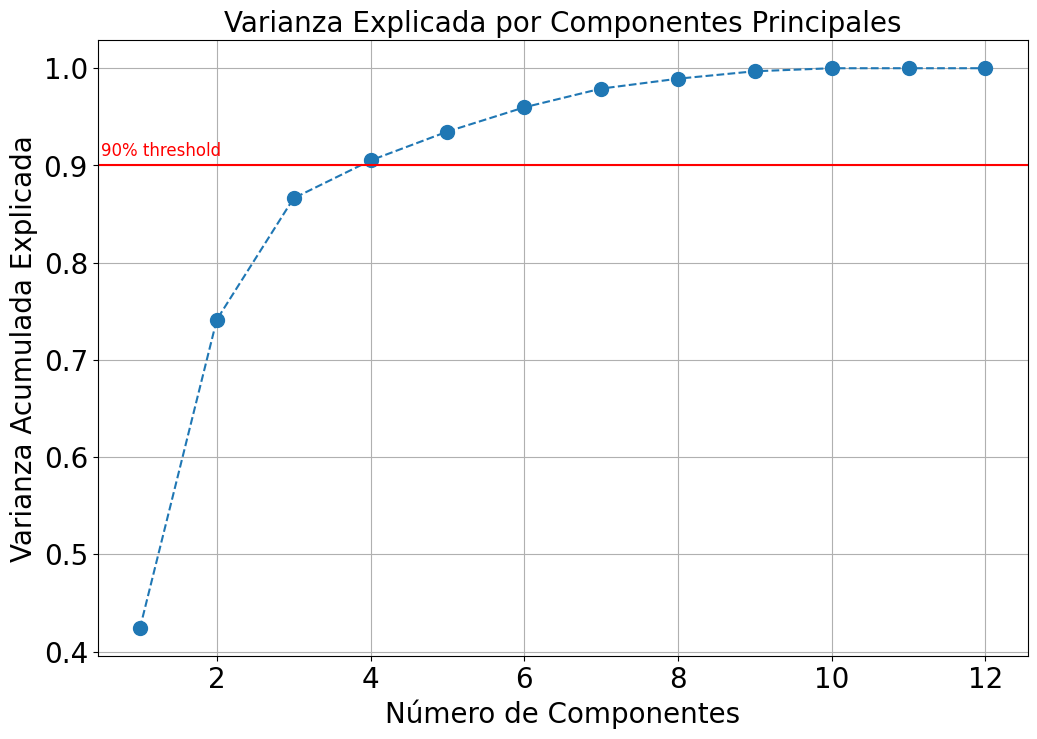

Number of components to retain to explain 90% of variance: 4


In [ ]:
from sklearn.decomposition import PCA

# Grafico de Varianza vs componentes necesarios

# Apply PCA
pca = PCA()
pca.fit(X_scaled)

# Calculate cumulative explained variance
cum_exp_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot explained variance
plt.figure(figsize=(12, 8)) # Aumentar el tamaño de la figura
plt.plot(range(1, len(cum_exp_variance) + 1), cum_exp_variance, marker='o', linestyle='--', markersize=10) # Aumentar el tamaño de los marcadores
plt.title('Varianza Explicada por Componentes Principales', fontsize=20) # Aumentar el tamaño del título
plt.xlabel('Número de Componentes', fontsize=20) # Aumentar el tamaño de la etiqueta del eje X
plt.ylabel('Varianza Acumulada Explicada', fontsize=20) # Aumentar el tamaño de la etiqueta del eje Y
plt.grid(True)

# Add horizontal line at 90% variance threshold
plt.axhline(y=0.90, color='r', linestyle='-')
plt.text(0.5, 0.91, '90% threshold', color = 'red', fontsize=12)

plt.tick_params(axis='x', labelsize=20) # Aumentar el tamaño de los números de los ticks en el eje X
plt.tick_params(axis='y', labelsize=20) # Aumentar el tamaño de los números de los ticks en el eje Y

plt.show()

# Determine the number of components to retain (e.g., to explain 90% of variance)
num_components_90 = np.where(cum_exp_variance >= 0.90)[0][0] + 1
print(f"Number of components to retain to explain 90% of variance: {num_components_90}")

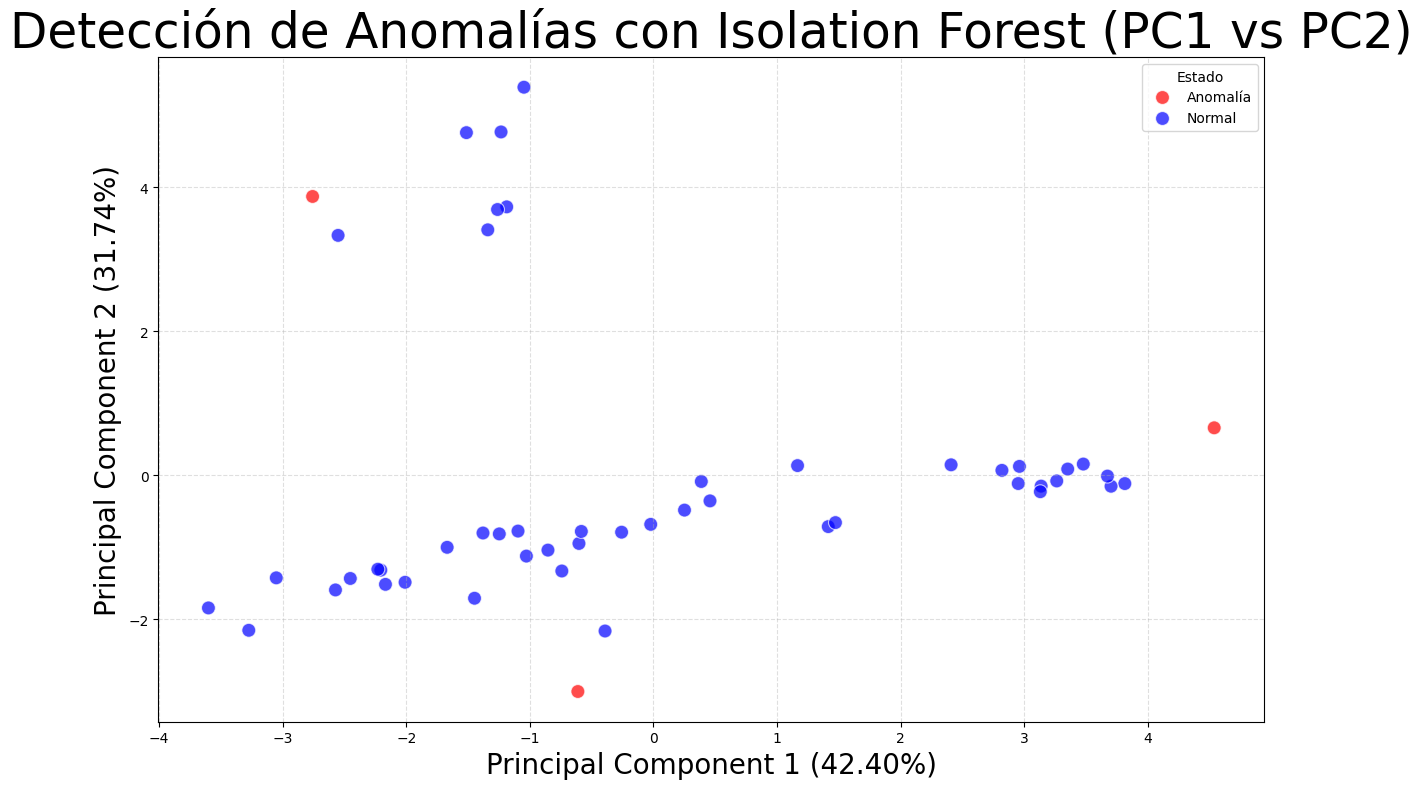

In [ ]:
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

# Analisis isolation Forest(Deteccion de anomalias)


# Assuming X_scaled and num_components_90 are already defined from previous steps
# Re-apply PCA with the determined number of components
pca_final = PCA(n_components=num_components_90) # num_components_90 was determined in a previous step
X_pca = pca_final.fit_transform(X_scaled)

# Inicializar el modelo Isolation Forest
# 'contamination' es la proporción esperada de outliers en el dataset.
# Si no tienes una estimación, puedes probar diferentes valores o dejar el valor por defecto ('auto').
# Usaremos random_state para reproducibilidad.
iso_forest = IsolationForest(contamination=0.05, random_state=42) # Se asume un 5% de anomalías

# Entrenar el modelo y predecir las anomalías
# fit_predict devuelve -1 para outliers y 1 para inliers
anomaly_predictions = iso_forest.fit_predict(X_pca)

# Añadir las predicciones al DataFrame de PCA para visualización
pca_df_anomalies = pd.DataFrame(data=X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
pca_df_anomalies['Anomaly'] = anomaly_predictions

# Convertir las etiquetas numéricas a algo más descriptivo para el hue del plot
pca_df_anomalies['Anomaly_Label'] = pca_df_anomalies['Anomaly'].map({1: 'Normal', -1: 'Anomalía'})

# Visualizar los resultados
# plt.rcParams['font.size'] = 30
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Anomaly_Label',
    palette={'Normal': 'blue', 'Anomalía': 'red'},
    data=pca_df_anomalies,
    s=100,
    alpha=0.7,
    edgecolor='w'
)

plt.title('Detección de Anomalías con Isolation Forest (PC1 vs PC2)', fontsize=35)
plt.xlabel(f'Principal Component 1 ({pca_final.explained_variance_ratio_[0]*100:.2f}%)', fontsize=20)
plt.ylabel(f'Principal Component 2 ({pca_final.explained_variance_ratio_[1]*100:.2f}%)', fontsize=20)
plt.legend(title='Estado')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

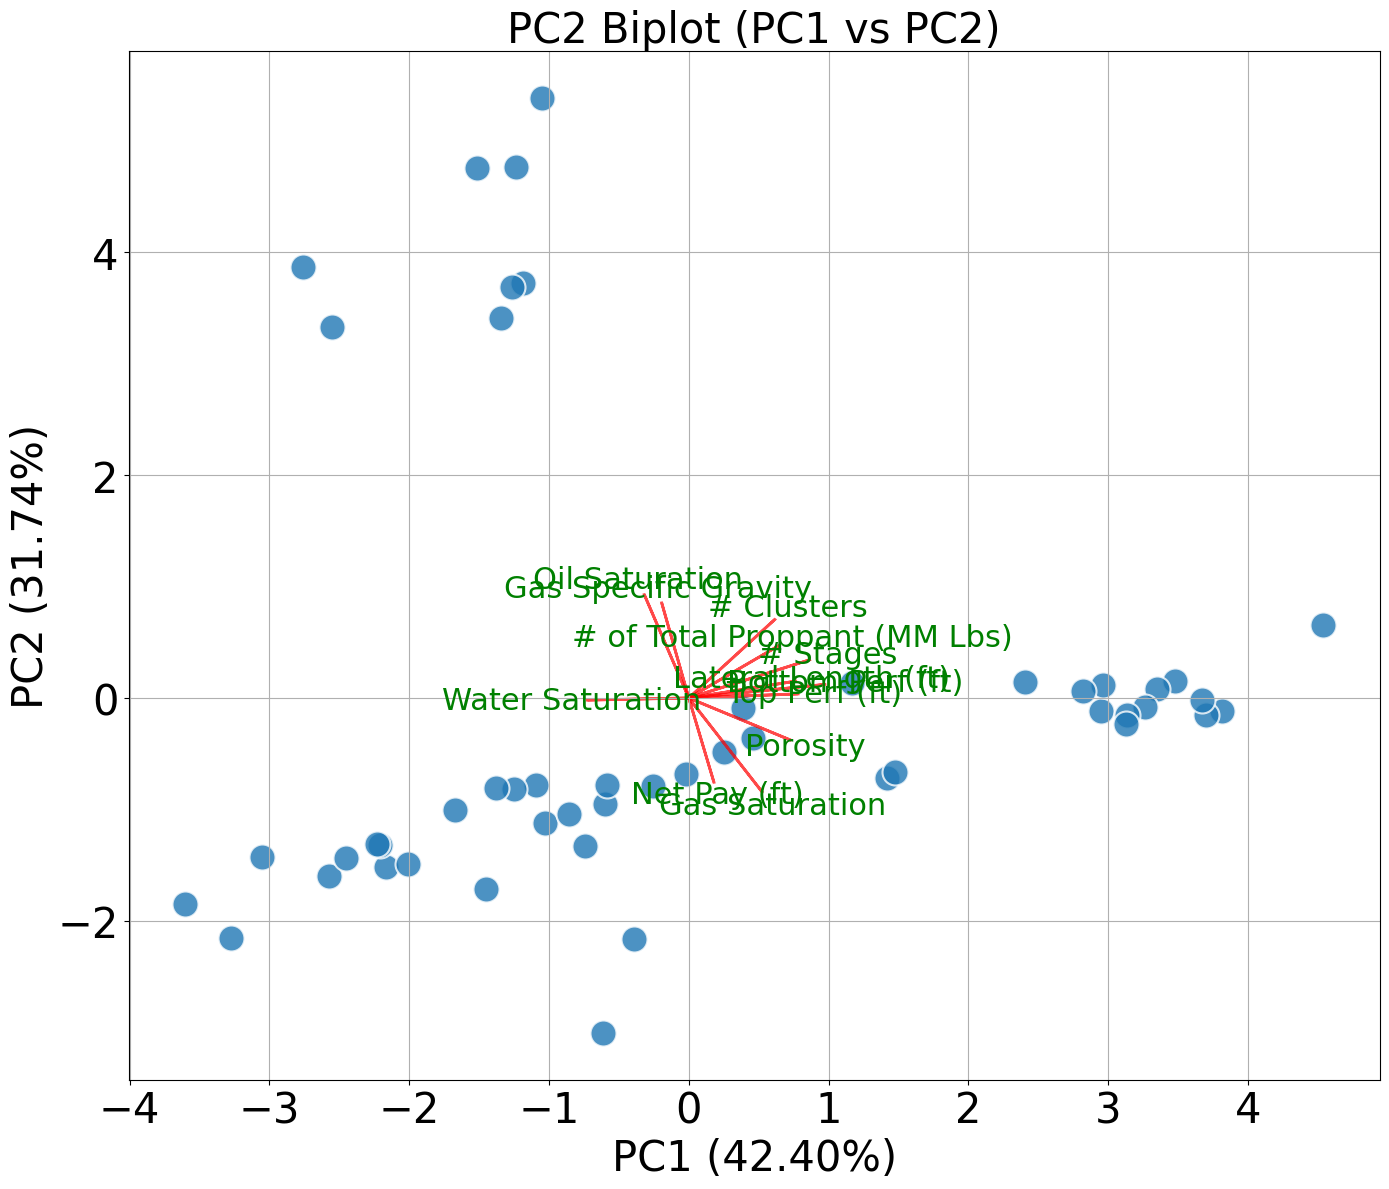

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Grafico de PCA (PC1 vs PC2)


# Re-apply PCA with the determined number of components (using num_components_90)
pca_final = PCA(n_components=num_components_90) # num_components_90 was determined in the previous step
X_pca = pca_final.fit_transform(X_scaled)

# Create a DataFrame for the PCA results
pca_df = pd.DataFrame(data=X_pca, columns=[f'PC{i+1}' for i in range(num_components_90)])

# Get the loadings (eigenvectors) of the principal components
loadings = pca_final.components_.T * np.sqrt(pca_final.explained_variance_)

# Create a DataFrame for loadings for easier plotting
loadings_df = pd.DataFrame(loadings, index=features_for_pca, columns=[f'PC{i+1}' for i in range(num_components_90)])

# Create the biplot
plt.figure(figsize=(14, 12)) # Aumentar el tamaño general de la figura
sns.scatterplot(
    x='PC1',
    y='PC2',
    data=pca_df,
    alpha=0.8, # Ajustar la transparencia de los puntos
    s=350,     # Aumentar el tamaño de los puntos
    edgecolor='w' # Borde blanco para los puntos
)

# Plot arrows for loadings
for i, feature in enumerate(features_for_pca):
    plt.arrow(
        0, 0,
        loadings[i, 0], # x end point
        loadings[i, 1], # y end point
        color='r',
        alpha=0.7,
        linewidth=2,    # Aumentar el grosor de la línea de la flecha
        head_width=0, # Eliminar la cabeza de la flecha
        head_length=0 # Eliminar la longitud de la cabeza de la flecha
    )
    plt.text(
        loadings[i, 0] * 1.15,
        loadings[i, 1] * 1.15,
        feature,
        color='g',
        ha='center',
        va='center',
        fontsize=22 # Aumentar el tamaño del texto de la característica
    )

plt.xlabel(f'PC1 ({pca_final.explained_variance_ratio_[0]*100:.2f}%)', fontsize=30) # Aumentar fontsize
plt.ylabel(f'PC2 ({pca_final.explained_variance_ratio_[1]*100:.2f}%)', fontsize=30) # Ajustar a PC2 con porcentaje, aumentar fontsize
plt.title('PC2 Biplot (PC1 vs PC2)', fontsize=30) # Aumentar fontsize
plt.grid()

# Aumentar el tamaño de los números de los ejes X y Y
plt.tick_params(axis='x', labelsize=30)
plt.tick_params(axis='y', labelsize=30)

plt.tight_layout() # Asegurar que todo quepa en la figura
plt.show()

**PC1**: Resume principalmente la intensidad del completamiento y la calidad de la roca. En el biplot se observa que # Stages, # Clusters, Total Proppant (MM Lbs), Lateral Length (ft) y Porosity apuntan hacia valores positivos de PC1, lo que indica que este componente distingue pozos con completamientos más robustos (más etapas, mayor densidad de disparos y mayor volumen de propante) y mejores propiedades petrofísicas. Esto coincide con la idea de que más etapas y más propante generan fracturas más grandes y mayor superficie de contacto, mientras que laterales más largos permiten drenar mayor volumen de roca. En la dirección opuesta aparecen Water Saturation y Gas Saturation, variables que se proyectan hacia valores negativos de PC1 y que se asocian a condiciones menos favorables en términos de calidad de roca y potencial de drenaje.

**PC2**: Captura diferencias asociadas principalmente al régimen de fluidos y a la composición interna del sistema. Las variables Oil Saturation y Gas Specific Gravity muestran cargas positivas importantes, lo que sugiere una mayor influencia de fracciones líquidas y gas más pesado en los pozos situados hacia valores altos de PC2. En contraste, Gas Saturation y Net Pay (ft) se proyectan hacia valores negativos de este componente, indicando pozos con gas más seco y mayor espesor neto productivo. En conjunto, PC2 complementa la caracterización del sistema al distinguir entre pozos con mezclas de fluidos más complejas (húmedas o pesadas) y pozos dominados por gas seco y mayor volumen de roca disponible.


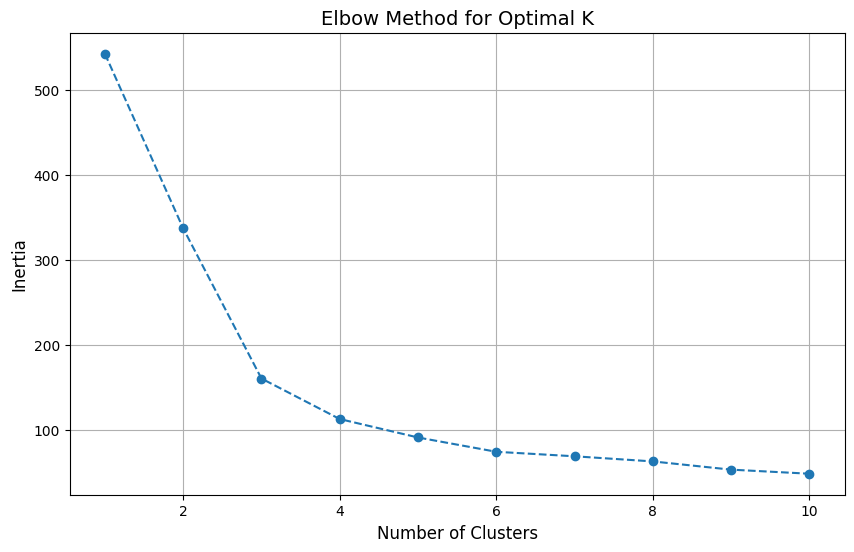

In [ ]:
# ============================================
# 14) Clustering Método del codo (encontrar el numero de clusters por K)
# Metodo Elbow
# ============================================


# Create an empty list to store inertia values
inertia_values = []

# Loop through a range of possible cluster numbers (e.g., from 1 to 10)
for i in range(1, 11): # Testing K from 1 to 10
    kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto') # n_init='auto' for KMeans warnings
    kmeans.fit(X_pca)
    inertia_values.append(kmeans.inertia_)

# Plot the inertia values against the range of cluster numbers
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia_values, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K', fontsize=14)
plt.xlabel('Number of Clusters', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.grid(True)
plt.show()


In [ ]:
optimal_k = 3 # Based on visual inspection of the Elbow Method plot

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
clusters = kmeans_final.fit_predict(X_pca)

print(f"K-Means clustering applied with optimal K = {optimal_k}.")
print(f"Cluster assignments for the first 5 data points: {clusters[:5]}")

K-Means clustering applied with optimal K = 3.
Cluster assignments for the first 5 data points: [2 2 2 2 2]


**MODELO K-MEANS CLUSTERING**

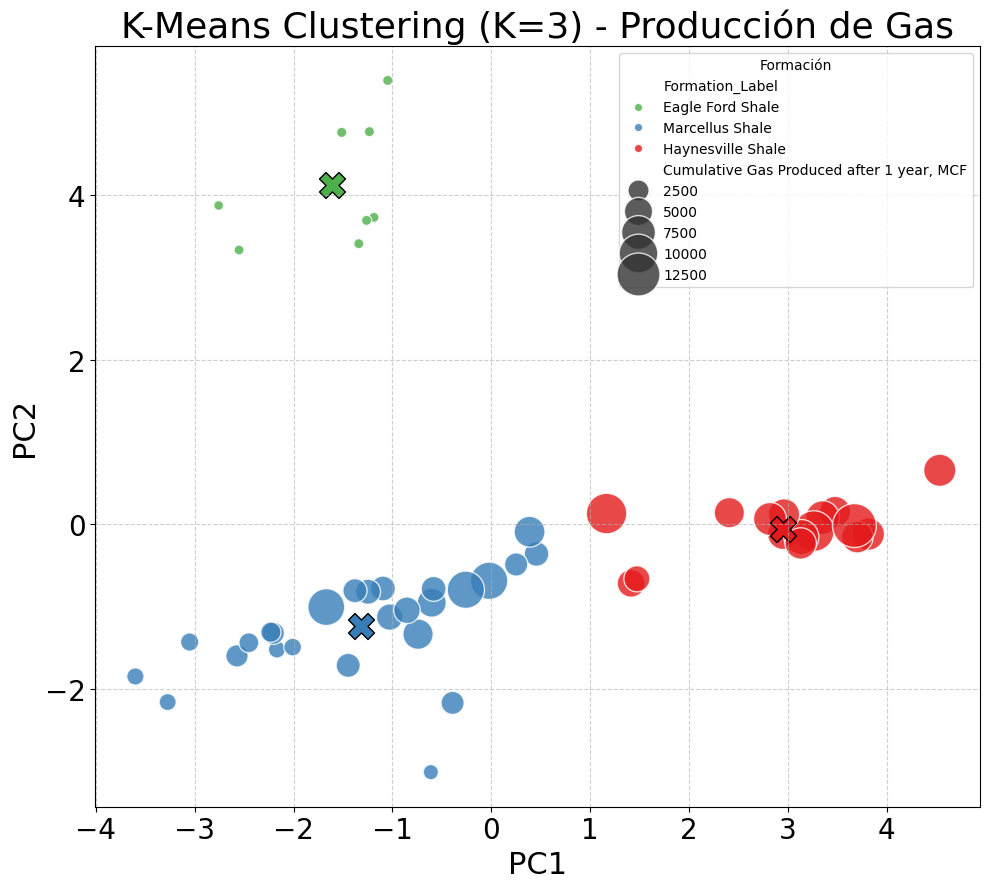

K-Means clusters with centroids visualized on PC1 vs PC2 plot for K = 3.


In [ ]:
# Grafico de K Means por centroides

# Define a custom color palette for consistency based on Set1 colors
set1_colors = sns.color_palette("Set1", 3)
custom_palette = {
    'Haynesville Shale': set1_colors[0],  # Red for Cluster 0
    'Marcellus Shale': set1_colors[1],    # Blue for Cluster 1
    'Eagle Ford Shale': set1_colors[2]    # Green for Cluster 2
}

# Create a DataFrame for PCA results with cluster assignments
pca_df_clusters = pd.DataFrame(data=X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
pca_df_clusters['Cluster'] = clusters

# Map cluster numbers to formation names (as defined previously)
cluster_to_formation = {
    0: 'Haynesville Shale',
    1: 'Marcellus Shale',
    2: 'Eagle Ford Shale'
}
pca_df_clusters['Formation_Label'] = pca_df_clusters['Cluster'].map(cluster_to_formation)

# Add the target variable to the pca_df_clusters DataFrame for analysis
pca_df_clusters['Cumulative Gas Produced after 1 year, MCF'] = df['Cumulative Gas Produced after 1 year, MCF']

# Get cluster centroids
centroids = kmeans_final.cluster_centers_

plt.figure(figsize=(10, 9))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Formation_Label', # Use the new formation label for hue
    size='Cumulative Gas Produced after 1 year, MCF', # Vary size by production (no log scaling)
    sizes=(50, 1000), # Define the range of sizes
    data=pca_df_clusters,
    palette=custom_palette, # Apply the custom palette
    alpha=0.8,
    edgecolor='w',
    linewidth=1 # Added linewidth for better visibility of edges
)

# Plot only centroids, without labels
for cluster_id, centroid in enumerate(centroids):
    formation_name = cluster_to_formation[cluster_id]
    color = custom_palette[formation_name]

    # Plot the centroid marker
    plt.scatter(
        centroid[0],
        centroid[1],
        marker='X',
        s=350, # Size of the centroid marker
        color=color, # Use the corresponding color for the centroid
        edgecolor='black',
        linewidth=1 # Added linewidth for centroid marker
    )

plt.title(f'K-Means Clustering (K={optimal_k}) - Producción de Gas', fontsize=26)
plt.xlabel('PC1', fontsize=22)
plt.ylabel('PC2', fontsize=22)
plt.legend(title='Formación', loc='upper right') # Update legend title
plt.grid(True, linestyle='--', alpha=0.6)

# Aumentar el tamaño de los números de los ejes X y Y
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)

plt.tight_layout()
plt.show()

print(f"K-Means clusters with centroids visualized on PC1 vs PC2 plot for K = {optimal_k}.")

El análisis de clústeres muestra una separación muy marcada por formación.
**El clúster rojo** (cluster 0) está compuesto casi en su totalidad por pozos de Haynesville Shale (93.3%) con una presencia marginal de Bossier Shale (6.7%), sin incluir pozos de Eagle Ford ni Marcellus.
**El clúster azul** (cluster 1) agrupa exclusivamente pozos de Marcellus (40.7%) y Marcellus Upper (59.3%)
**El clúster verde** (cluster 2) está formado en un 100% por pozos de Eagle Ford. Estos resultados indican que la segmentación por K-Means refleja de manera consistente las diferencias geológicas entre formaciones , mostrando que cada grupo conserva una identidad litológica bien delimitada. Además, la ubicación de los centroides dentro del plano PC1–PC2 confirma que los clústeres no solo difieren en formación, sino también en el comportamiento multivariado de las propiedades petrofísicas y de completamiento asociadas a cada uno de ellos.

In [ ]:
print("Top 5 formations in the dataset:")
display(df['Formation'].value_counts().nlargest(5))

Top 5 formations in the dataset:


,count
Formation,
MARCELLUS_UPPER,16
HAYNESVILLE_SHALE,14
MARCELLUS,11
EAGLE_FORD,8
BOSSIER_SHALE,1


Based on the above counts, the top 5 formations are likely to be used for the 5-cluster K-Means plot. We will now run K-Means with `K=5`.

In [ ]:
# Re-run K-Means with optimal K = 5 for the top 5 formations
optimal_k_5 = 5
kmeans_final_5 = KMeans(n_clusters=optimal_k_5, random_state=42, n_init='auto')
clusters_5 = kmeans_final_5.fit_predict(X_pca)

print(f"K-Means clustering applied with optimal K = {optimal_k_5}.")

# Create a DataFrame for PCA results with new cluster assignments
pca_df_clusters_5 = pd.DataFrame(data=X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
pca_df_clusters_5['Cluster'] = clusters_5

# Add the original 'Formation' column to analyze cluster composition
pca_df_clusters_5['Original_Formation'] = df['Formation']

# Analyze the dominant formation for each cluster
cluster_formation_mapping_5 = {}
for cluster_id in sorted(pca_df_clusters_5['Cluster'].unique()):
    dominant_formation = pca_df_clusters_5[pca_df_clusters_5['Cluster'] == cluster_id]['Original_Formation'].mode()[0]
    cluster_formation_mapping_5[cluster_id] = dominant_formation

print("\nDominant formation in each new cluster:")
print(cluster_formation_mapping_5)

# Map new cluster numbers to formation names
pca_df_clusters_5['Formation_Label'] = pca_df_clusters_5['Cluster'].map(cluster_formation_mapping_5)

# Add the target variable to the pca_df_clusters_5 DataFrame for analysis
pca_df_clusters_5['Cumulative Gas Produced after 1 year, MCF'] = df['Cumulative Gas Produced after 1 year, MCF']

K-Means clustering applied with optimal K = 5.

Dominant formation in each new cluster:
{np.int32(0): 'HAYNESVILLE_SHALE', np.int32(1): 'MARCELLUS', np.int32(2): 'EAGLE_FORD', np.int32(3): 'MARCELLUS_UPPER', np.int32(4): 'MARCELLUS_UPPER'}


**K-Means Clustering Plot for 5 Formations**

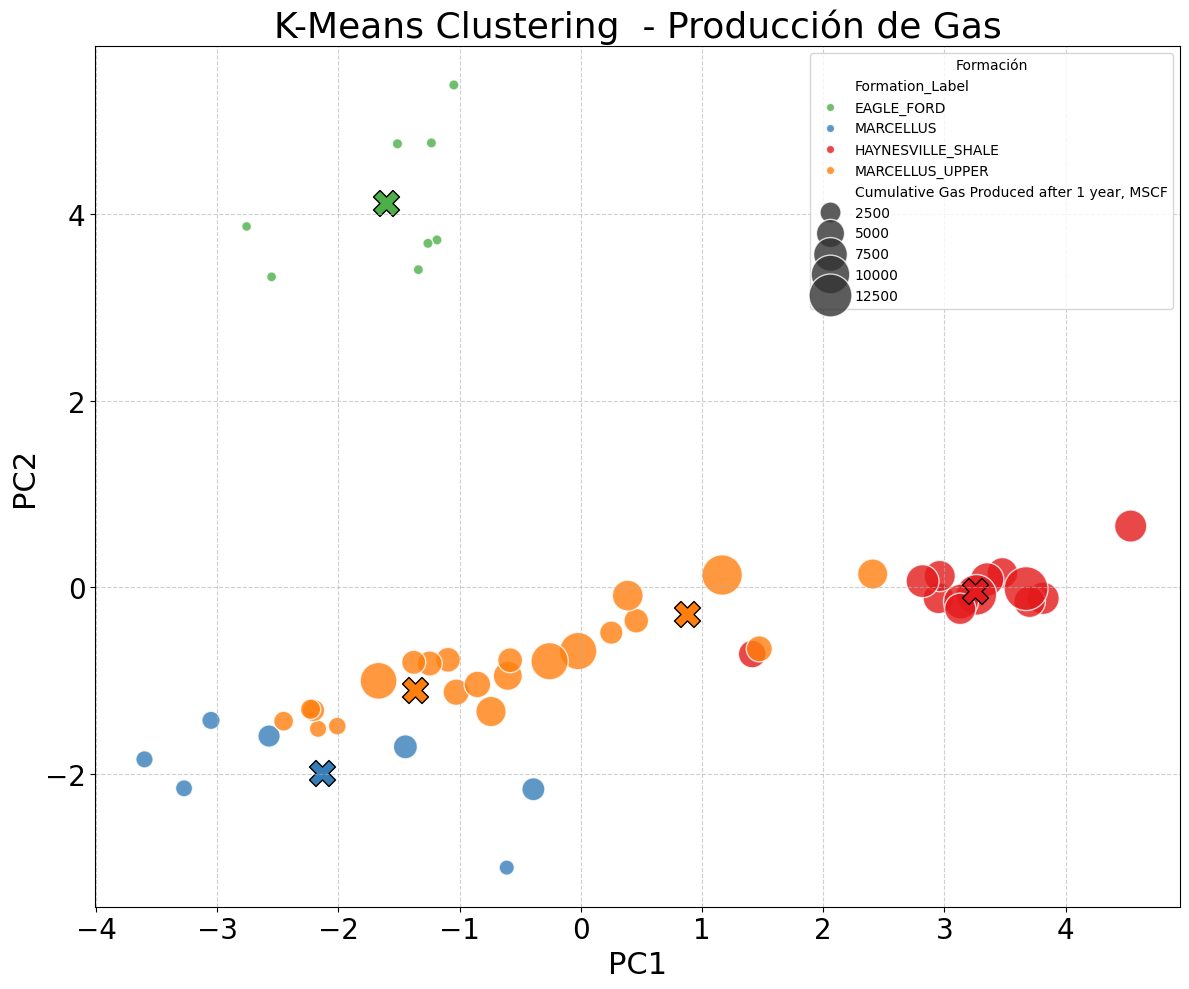

K-Means clusters with centroids visualized on PC1 vs PC2 plot for K = 5.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Define a custom color palette for 5 clusters
# Using Set1 colors for the main formations and an additional color for MARCELLUS_UPPER
set1_colors = sns.color_palette("Set1", 3) # Red, Blue, Green
tab10_colors = sns.color_palette("tab10") # For additional distinct colors

color_map_for_5_clusters = {
    'HAYNESVILLE_SHALE': set1_colors[0],  # Red
    'MARCELLUS': set1_colors[1],          # Blue
    'EAGLE_FORD': set1_colors[2],         # Green
    'MARCELLUS_UPPER': tab10_colors[1]    # Naranja (segundo color de tab10, suele ser naranja)
}

# Convert 'Cumulative Gas Produced after 1 year, MCF' to 'Cumulative Gas Produced after 1 year, CF' (pies cúbicos)
pca_df_clusters_5['Cumulative Gas Produced after 1 year, CF'] = pca_df_clusters_5['Cumulative Gas Produced after 1 year, MCF'] * 1000

# Convert 'Cumulative Gas Produced after 1 year, CF' to 'Miles de Pies Cúbicos' (MSCF)
pca_df_clusters_5['Cumulative Gas Produced after 1 year, MSCF'] = pca_df_clusters_5['Cumulative Gas Produced after 1 year, CF'] / 1000

plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Formation_Label', # Use the new formation label for hue
    size='Cumulative Gas Produced after 1 year, MSCF', # Vary size by production in thousands of cubic feet
    sizes=(50, 1000), # Define the range of sizes
    data=pca_df_clusters_5,
    palette=color_map_for_5_clusters, # Apply the custom palette
    alpha=0.8,
    edgecolor='w',
    linewidth=1 # Added linewidth for better visibility of edges
)

# Get cluster centroids for the new K=5 model
centroids_5 = kmeans_final_5.cluster_centers_

# Plot only centroids, without labels, using consistent colors
for cluster_id, centroid in enumerate(centroids_5):
    formation_name = cluster_formation_mapping_5[cluster_id]
    color = color_map_for_5_clusters[formation_name] # Use the custom color map

    # Plot the centroid marker
    plt.scatter(
        centroid[0],
        centroid[1],
        marker='X',
        s=350, # Size of the centroid marker
        color=color, # Use the corresponding color for the centroid
        edgecolor='black',
        linewidth=1 # Added linewidth for centroid marker
    )

plt.title(f'K-Means Clustering  - Producción de Gas', fontsize=26)
plt.xlabel('PC1', fontsize=22)
plt.ylabel('PC2', fontsize=22)
plt.legend(title='Formación', loc='upper right') # Update legend title
plt.grid(True, linestyle='--', alpha=0.6)

# Aumentar el tamaño de los números de los ejes X y Y
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)

plt.tight_layout()
plt.show()

print(f"K-Means clusters with centroids visualized on PC1 vs PC2 plot for K = {optimal_k_5}.")

In [ ]:
# Calculate and display descriptive statistics for 'Cumulative Gas Produced after 1 year, MCF' grouped by Formation_Label
# Ensure 'pca_df_clusters' DataFrame is available
try:
    pca_df_clusters
except NameError:
    print("DataFrame 'pca_df_clusters' not found. Please run previous cells.")
    exit()

production_stats = pca_df_clusters.groupby('Formation_Label')['Cumulative Gas Produced after 1 year, MCF'].agg(['mean', 'min', 'max', 'std']).round(2)

print("Descriptive statistics for Cumulative Gas Produced per Formation:")
print(production_stats)

Descriptive statistics for Cumulative Gas Produced per Formation:
                      mean      min       max      std
Formation_Label                                       
Eagle Ford Shale     66.31    25.13     93.92    21.31
Haynesville Shale  7354.84  4182.70  13094.85  2406.36
Marcellus Shale    3873.20   996.88   9274.80  2374.98


**MODELO JERARQUICO CLUSTERING**

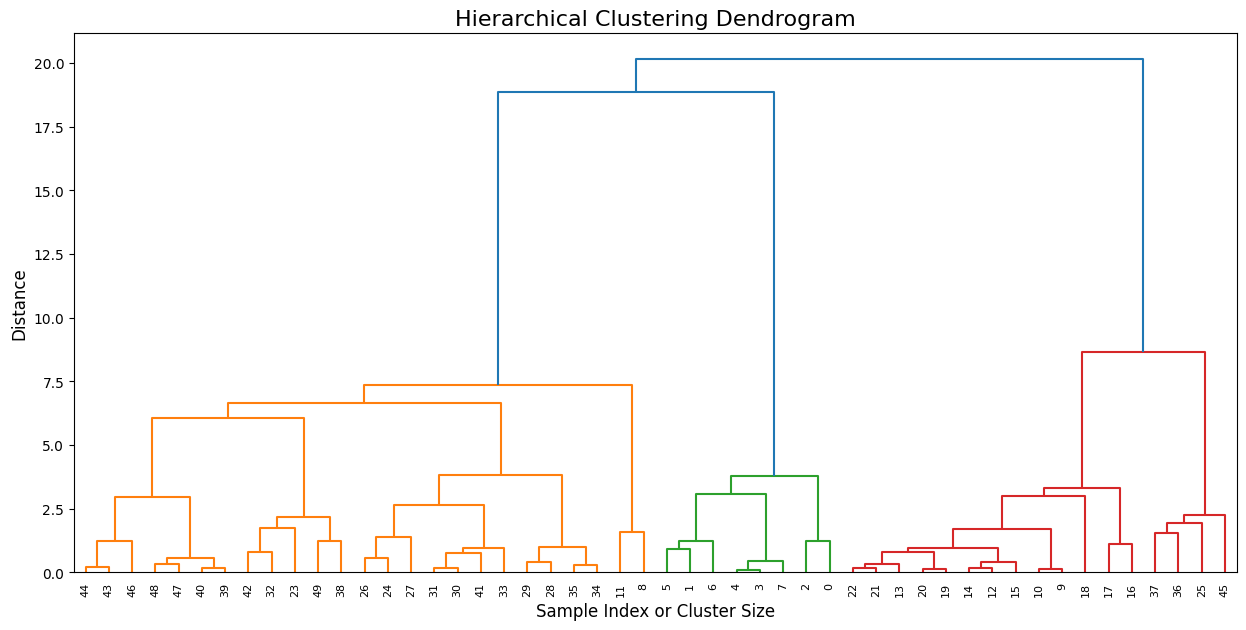

In [ ]:
# Agrupamiento Jerarquico (Dendograma):

# Compute the linkage matrix using the 'ward' method
linked_data = linkage(X_pca, method='ward')

# Plot the dendrogram
plt.figure(figsize=(15, 7))
dendrogram(
    linked_data,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=True
)
plt.title('Hierarchical Clustering Dendrogram', fontsize=16)
plt.xlabel('Sample Index or Cluster Size', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.show()

El **Dendrograma:** representa cómo los pozos se agrupan según su similitud multivariable mediante clustering jerárquico. En este tipo de gráfico:

**El eje X** no corresponde a ninguna variable de la base de datos, sino simplemente al orden secuencial de las muestras (índices de pozos) después del procesamiento, lo que permite visualizar cada pozo como una hoja en la base del dendrograma.

**El eje Y** muestra la altura o distancia de fusión entre los grupos; estos valores son generados matemáticamente por el algoritmo a partir de las distancias entre pozos ya estandarizados y no representan números presentes en el archivo original. Una mayor altura implica que los grupos que se unen en ese punto son más diferentes entre sí. En este caso, la estructura del dendrograma evidencia que las fusiones principales ocurren a alturas relativamente altas (del orden de ~18 a ~20), lo que indica que existen tres grupos bien separados, coherentes con los clústeres identificados previamente mediante K‑Means.

In [ ]:
from scipy.cluster.hierarchy import fcluster
import numpy as np

# Assuming an optimal number of clusters (e.g., 3) based on the dendrogram analysis
# The 'max_d' parameter in fcluster refers to the criterion for forming flat clusters.
# If criterion is 'maxclust', max_d is interpreted as the number of clusters.
optimal_hierarchical_k = 3 # Based on visual inspection of the dendrogram

hierarchical_clusters = fcluster(linked_data, optimal_hierarchical_k, criterion='maxclust')

print(f"Hierarchical clustering applied with {optimal_hierarchical_k} clusters.")
print(f"Cluster assignments for the first 5 data points: {hierarchical_clusters[:5]}")

Hierarchical clustering applied with 3 clusters.
Cluster assignments for the first 5 data points: [2 2 2 2 2]


In [ ]:
# ==================================================
# 15) Modelos Predictivos con Componentes Principales
# ==================================================

# Define the target variable 'y'
y = df[target_variable]

# Dividir los componentes principales en conjuntos de entrenamiento y prueba
# Usamos el mismo random_state para consistencia con las divisiones anteriores
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42)

print("Datos PCA divididos en entrenamiento y prueba.")
print(f"Shape de X_train_pca: {X_train_pca.shape}")
print(f"Shape de X_test_pca: {X_test_pca.shape}")

Datos PCA divididos en entrenamiento y prueba.
Shape de X_train_pca: (40, 4)
Shape de X_test_pca: (10, 4)


**MODELO RANDOM FOREST**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
import numpy as np
import pandas as pd

# SE IDENTIFICAN LAS 4 VARIABLES MAS IMPORTANTES ENTRE
#PROPIEDADES PETROFISICAS Y DE COMPLETAMIENTO

# 3. Identify and select the top 4 most important features
top_4_features = feature_importance_df['feature'].head(4).tolist()
print(f"Top 4 most important features: {top_4_features}")

# 4. Create new training and testing feature sets
X_train_top4 = X_train[top_4_features]
X_test_top4 = X_test[top_4_features]

# 5. Initialize a new RandomForestRegressor with the same parameters
rf_model_top4 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 6. Train this new model
rf_model_top4.fit(X_train_top4, y_train)

# 7. Make predictions on X_test_top4
y_pred_rf_top4 = rf_model_top4.predict(X_test_top4)

# 8. Calculate and print the evaluation metrics
mse_rf_top4 = mean_squared_error(y_test, y_pred_rf_top4)
rmse_rf_top4 = np.sqrt(mse_rf_top4)
r2_rf_top4 = r2_score(y_test, y_pred_rf_top4)

# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_rf_top4 = cross_val_score(rf_model_top4, X[top_4_features], y, cv=kf, scoring='r2')
cv_mse_rf_top4 = -cross_val_score(rf_model_top4, X[top_4_features], y, cv=kf, scoring='neg_mean_squared_error')

print(f"\nRandom Forest Regressor (Top 4 Features) Model Evaluation:")
print(f"  Mean Squared Error (MSE): {mse_rf_top4:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_rf_top4:.2f}")
print(f"  R-squared (R2): {r2_rf_top4:.2f}")
print(f"  Cross-validated R-squared: {np.mean(cv_r2_rf_top4):.2f} (+/- {np.std(cv_r2_rf_top4):.2f})")
print(f"  Cross-validated MSE: {np.mean(cv_mse_rf_top4):.2f} (+/- {np.std(cv_mse_rf_top4):.2f})")


Top 4 most important features: ['Bottom Perf (ft)', 'Lateral Length (ft)', 'Porosity', 'Gas Saturation']

Random Forest Regressor (Top 4 Features) Model Evaluation:
  Mean Squared Error (MSE): 3628058.51
  Root Mean Squared Error (RMSE): 1904.75
  R-squared (R2): 0.53
  Cross-validated R-squared: 0.62 (+/- 0.10)
  Cross-validated MSE: 3818931.59 (+/- 1715131.73)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# 1. Split the original data (X, y) into training and testing sets
# This is necessary as X_train and y_train were not explicitly defined before
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train a RandomForestRegressor to get feature importances
# This re-creates feature_importance_df, which was missing
rf_model_for_importances = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_for_importances.fit(X_train, y_train)

# Create feature_importance_df
feature_importance_df = pd.DataFrame(
    {'feature': X_train.columns,
     'importance': rf_model_for_importances.feature_importances_}
).sort_values(by='importance', ascending=False)

# 3. Identificar y seleccionar las 4 características más importantes
top_4_features = feature_importance_df['feature'].head(4).tolist()

# 4. Crear nuevos conjuntos de características de entrenamiento y prueba
X_train_top4 = X_train[top_4_features]
X_test_top4 = X_test[top_4_features]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Top 4 most important features: {top_4_features}")
print(f"X_train_top4 shape: {X_train_top4.shape}")
print(f"X_test_top4 shape: {X_test_top4.shape}")

X_train shape: (40, 12)
X_test shape: (10, 12)
Top 4 most important features: ['Bottom Perf (ft)', 'Lateral Length (ft)', 'Porosity', 'Gas Saturation']
X_train_top4 shape: (40, 4)
X_test_top4 shape: (10, 4)


**MODELO DE REGRESION MULTIPLE**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# Initialize the Multiple Linear Regression model
mlr_model_top4 = LinearRegression()

# Train the model using X_train_top4 and y_train
mlr_model_top4.fit(X_train_top4, y_train)

# Make predictions on the test set
y_pred_mlr_top4 = mlr_model_top4.predict(X_test_top4)

# Evaluate the model
mse_mlr_top4 = mean_squared_error(y_test, y_pred_mlr_top4)
rmse_mlr_top4 = np.sqrt(mse_mlr_top4)
r2_mlr_top4 = r2_score(y_test, y_pred_mlr_top4)

# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_mlr_top4 = cross_val_score(mlr_model_top4, X[top_4_features], y, cv=kf, scoring='r2')
cv_mse_mlr_top4 = -cross_val_score(mlr_model_top4, X[top_4_features], y, cv=kf, scoring='neg_mean_squared_error')

print(f"Multiple Linear Regression Model (Top 4 Features) Evaluation:")
print(f"  Mean Squared Error (MSE): {mse_mlr_top4:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_mlr_top4:.2f}")
print(f"  R-squared (R2): {r2_mlr_top4:.2f}")
print(f"  Cross-validated R-squared: {np.mean(cv_r2_mlr_top4):.2f} (+/- {np.std(cv_r2_mlr_top4):.2f})")
print(f"  Cross-validated MSE: {np.mean(cv_mse_mlr_top4):.2f} (+/- {np.std(cv_mse_mlr_top4):.2f})")

print("\nModel Coefficients (Top 4 Features):")
for feature, coef in zip(X_train_top4.columns, mlr_model_top4.coef_):
    print(f"  {feature}: {coef:.2f}")
print(f"  Intercept: {mlr_model_top4.intercept_:.2f}")


Multiple Linear Regression Model (Top 4 Features) Evaluation:
  Mean Squared Error (MSE): 3957686.19
  Root Mean Squared Error (RMSE): 1989.39
  R-squared (R2): 0.49
  Cross-validated R-squared: 0.59 (+/- 0.13)
  Cross-validated MSE: 4134439.39 (+/- 1830224.20)

Model Coefficients (Top 4 Features):
  Bottom Perf (ft): -0.21
  Lateral Length (ft): 0.71
  Porosity: 132605.23
  Gas Saturation: 2902.26
  Intercept: -8653.35


**MODELO XG BOOST**

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# Initialize the XGBoost Regressor model
# You can tune hyperparameters like n_estimators, learning_rate, max_depth
xgb_model_top4 = xgb.XGBRegressor(
    objective='reg:squarederror', # Objective for regression tasks
    n_estimators=100,             # Number of boosting rounds
    learning_rate=0.1,            # Step size shrinkage
    max_depth=5,                  # Maximum depth of a tree
    random_state=42,              # For reproducibility
    n_jobs=-1                     # Use all available cores
)

# Train the model
xgb_model_top4.fit(X_train_top4, y_train)

# Make predictions on the test set
y_pred_xgb_top4 = xgb_model_top4.predict(X_test_top4)

# Evaluate the model
mse_xgb_top4 = mean_squared_error(y_test, y_pred_xgb_top4)
rmse_xgb_top4 = np.sqrt(mse_xgb_top4)
r2_xgb_top4 = r2_score(y_test, y_pred_xgb_top4)

# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_xgb_top4 = cross_val_score(xgb_model_top4, X[top_4_features], y, cv=kf, scoring='r2')
cv_mse_xgb_top4 = -cross_val_score(xgb_model_top4, X[top_4_features], y, cv=kf, scoring='neg_mean_squared_error')

print(f"XGBoost Regressor Model (Top 4 Features) Evaluation:")
print(f"  Mean Squared Error (MSE): {mse_xgb_top4:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_xgb_top4:.2f}")
print(f"  R-squared (R2): {r2_xgb_top4:.2f}")
print(f"  Cross-validated R-squared: {np.mean(cv_r2_xgb_top4):.2f} (+/- {np.std(cv_r2_xgb_top4):.2f})")
print(f"  Cross-validated MSE: {np.mean(cv_mse_xgb_top4):.2f} (+/- {np.std(cv_mse_xgb_top4):.2f})")


XGBoost Regressor Model (Top 4 Features) Evaluation:
  Mean Squared Error (MSE): 5662109.25
  Root Mean Squared Error (RMSE): 2379.52
  R-squared (R2): 0.27
  Cross-validated R-squared: 0.47 (+/- 0.15)
  Cross-validated MSE: 5053218.14 (+/- 1507380.85)


### **MODELO LASSO REGRESSION**

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# Initialize the Lasso Regressor model for top 4 features
# Alpha is the regularization strength; you might need to tune this.
lasso_model_top4 = Lasso(alpha=1.0, random_state=42)

# Train the model
lasso_model_top4.fit(X_train_top4, y_train)

# Make predictions on the test set
y_pred_lasso_top4 = lasso_model_top4.predict(X_test_top4)

# Evaluate the model
mse_lasso_top4 = mean_squared_error(y_test, y_pred_lasso_top4)
rmse_lasso_top4 = np.sqrt(mse_lasso_top4)
r2_lasso_top4 = r2_score(y_test, y_pred_lasso_top4)

# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_lasso_top4 = cross_val_score(lasso_model_top4, X[top_4_features], y, cv=kf, scoring='r2')
cv_mse_lasso_top4 = -cross_val_score(lasso_model_top4, X[top_4_features], y, cv=kf, scoring='neg_mean_squared_error')

print(f"Lasso Regressor Model (Top 4 Features) Evaluation:")
print(f"  Mean Squared Error (MSE): {mse_lasso_top4:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_lasso_top4:.2f}")
print(f"  R-squared (R2): {r2_lasso_top4:.2f}")
print(f"  Cross-validated R-squared: {np.mean(cv_r2_lasso_top4):.2f} (+/- {np.std(cv_r2_lasso_top4):.2f})")
print(f"  Cross-validated MSE: {np.mean(cv_mse_lasso_top4):.2f} (+/- {np.std(cv_mse_lasso_top4):.2f})")

print("\nModel Coefficients (Top 4 Features, Lasso):")
for feature, coef in zip(X_train_top4.columns, lasso_model_top4.coef_):
    print(f"  {feature}: {coef:.2f}")
print(f"  Intercept: {lasso_model_top4.intercept_:.2f}")


Lasso Regressor Model (Top 4 Features) Evaluation:
  Mean Squared Error (MSE): 3644536.30
  Root Mean Squared Error (RMSE): 1909.07
  R-squared (R2): 0.53
  Cross-validated R-squared: 0.59 (+/- 0.13)
  Cross-validated MSE: 4156472.17 (+/- 2020327.48)

Model Coefficients (Top 4 Features, Lasso):
  Bottom Perf (ft): -0.13
  Lateral Length (ft): 0.62
  Porosity: 106756.66
  Gas Saturation: 3523.80
  Intercept: -7950.06


### **MODELO RIDGE**

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# Initialize the Ridge Regressor model for top 4 features
# Alpha is the regularization strength; you might need to tune this.
ridge_model_top4 = Ridge(alpha=1.0, random_state=42)

# Train the model
ridge_model_top4.fit(X_train_top4, y_train)

# Make predictions on the test set
y_pred_ridge_top4 = ridge_model_top4.predict(X_test_top4)

# Evaluate the model
mse_ridge_top4 = mean_squared_error(y_test, y_pred_ridge_top4)
rmse_ridge_top4 = np.sqrt(mse_ridge_top4)
r2_ridge_top4 = r2_score(y_test, y_pred_ridge_top4)

# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_ridge_top4 = cross_val_score(ridge_model_top4, X[top_4_features], y, cv=kf, scoring='r2')
cv_mse_ridge_top4 = -cross_val_score(ridge_model_top4, X[top_4_features], y, cv=kf, scoring='neg_mean_squared_error')

print(f"Ridge Regressor Model (Top 4 Features) Evaluation:")
print(f"  Mean Squared Error (MSE): {mse_ridge_top4:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_ridge_top4:.2f}")
print(f"  R-squared (R2): {r2_ridge_top4:.2f}")
print(f"  Cross-validated R-squared: {np.mean(cv_r2_ridge_top4):.2f} (+/- {np.std(cv_r2_ridge_top4):.2f})")
print(f"  Cross-validated MSE: {np.mean(cv_mse_ridge_top4):.2f} (+/- {np.std(cv_mse_ridge_top4):.2f})")

print("\nModel Coefficients (Top 4 Features, Ridge):")
for feature, coef in zip(X_train_top4.columns, ridge_model_top4.coef_):
    print(f"  {feature}: {coef:.2f}")
print(f"  Intercept: {ridge_model_top4.intercept_:.2f}")


Ridge Regressor Model (Top 4 Features) Evaluation:
  Mean Squared Error (MSE): 3590087.14
  Root Mean Squared Error (RMSE): 1894.75
  R-squared (R2): 0.53
  Cross-validated R-squared: 0.55 (+/- 0.14)
  Cross-validated MSE: 4688143.42 (+/- 2549926.97)

Model Coefficients (Top 4 Features, Ridge):
  Bottom Perf (ft): 0.26
  Lateral Length (ft): 0.26
  Porosity: 312.83
  Gas Saturation: 4605.89
  Intercept: -4981.44


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Collect all metrics for the models (using top 4 features)
model_metrics = {
    'Model': ['Random Forest (Top 4)', 'Linear Regression (Top 4)', 'XGBoost (Top 4)', 'Lasso Regression (Top 4)', 'Ridge Regression (Top 4)'],
    'R-squared': [r2_rf_top4, r2_mlr_top4, r2_xgb_top4, r2_lasso_top4, r2_ridge_top4],
    'R-squared (CV)': [np.mean(cv_r2_rf_top4), np.mean(cv_r2_mlr_top4), np.mean(cv_r2_xgb_top4), np.mean(cv_r2_lasso_top4), np.mean(cv_r2_ridge_top4)],
    'MSE': [mse_rf_top4, mse_mlr_top4, mse_xgb_top4, mse_lasso_top4, mse_ridge_top4],
    'MSE (CV)': [np.mean(cv_mse_rf_top4), np.mean(cv_mse_mlr_top4), np.mean(cv_mse_xgb_top4), np.mean(cv_mse_lasso_top4), np.mean(cv_mse_ridge_top4)],
    'RMSE': [rmse_rf_top4, rmse_mlr_top4, rmse_xgb_top4, rmse_lasso_top4, rmse_ridge_top4]
}

all_performance_df = pd.DataFrame(model_metrics)

print("Tabla de rendimiento completa de los modelos (Top 4 Features):")
display(all_performance_df)


Tabla de rendimiento completa de los modelos (Top 4 Features):


,Model,R-squared,R-squared (CV),MSE,MSE (CV),RMSE
0,Random Forest (Top 4),0.529729,0.618197,3.628059e+06,3.818932e+06,1904.746311
1,Linear Regression (Top 4),0.487002,0.585680,3.957686e+06,4.134439e+06,1989.393422
2,XGBoost (Top 4),0.266074,0.470747,5.662109e+06,5.053218e+06,2379.518701
3,Lasso Regression (Top 4),0.527593,0.589014,3.644536e+06,4.156472e+06,1909.066867
4,Ridge Regression (Top 4),0.534651,0.547135,3.590087e+06,4.688143e+06,1894.752528


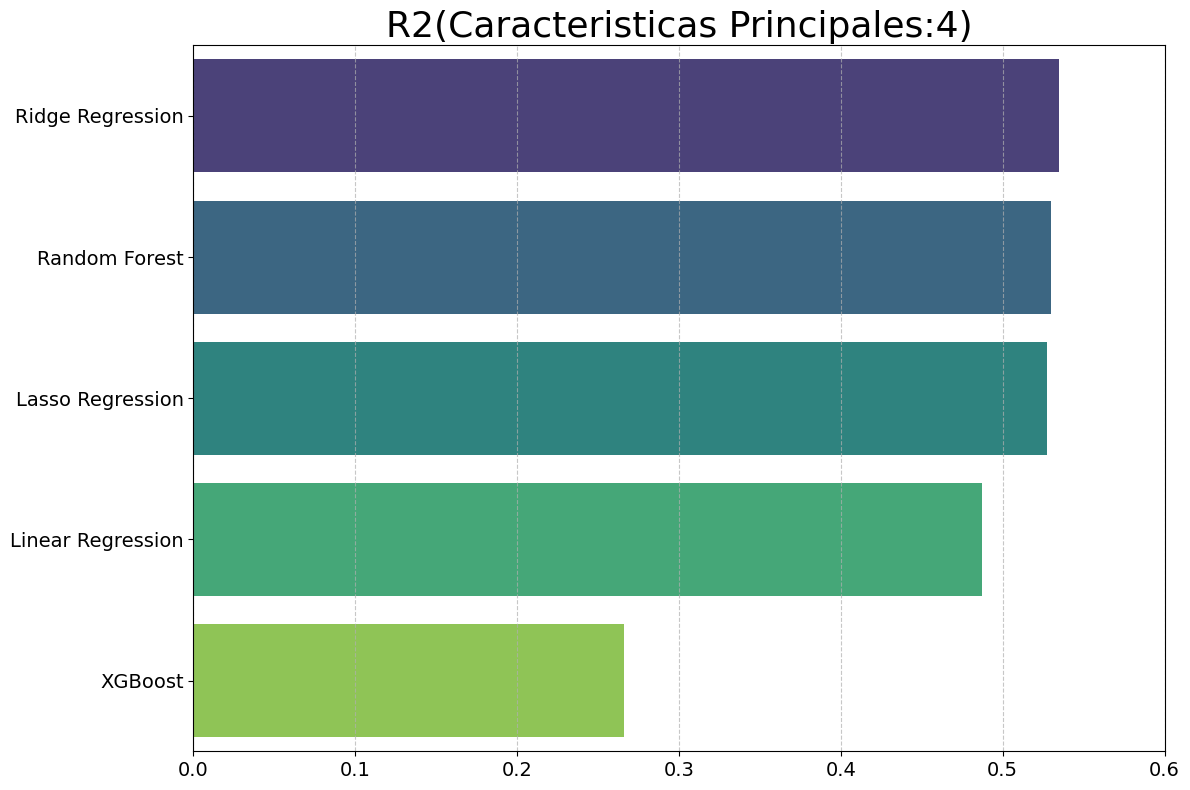

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ============================================
# Gráfico de Barras de R2 para Comparación de Modelos (Top 4 Features)
# ============================================

# Create a DataFrame for easy plotting from the filtered performance
performance_df_r2 = all_performance_df.copy()
# Remove '(Top 4)' from model names for cleaner labels on the plot
performance_df_r2['Model'] = performance_df_r2['Model'].str.replace(' (Top 4)', '', regex=False)
performance_df_r2 = performance_df_r2.sort_values(by='R-squared', ascending=False)

# Create the bar plot
plt.figure(figsize=(12, 8))
sns.barplot(
    x='R-squared',
    y='Model',
    hue='Model',
    data=performance_df_r2,
    palette='viridis',
    legend=False
)
plt.title('R2(Caracteristicas Principales:4)', fontsize=26) # Aumentar el tamaño de la fuente del título
plt.xlabel('')
plt.ylabel('')
plt.xlim(0, 0.6) # R-squared typically ranges from 0 to 1, adjusted to 0.6
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Aumentar el tamaño de los números de los ejes X y Y
plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

### Gráfico de Araña para Mean Squared Error (MSE)

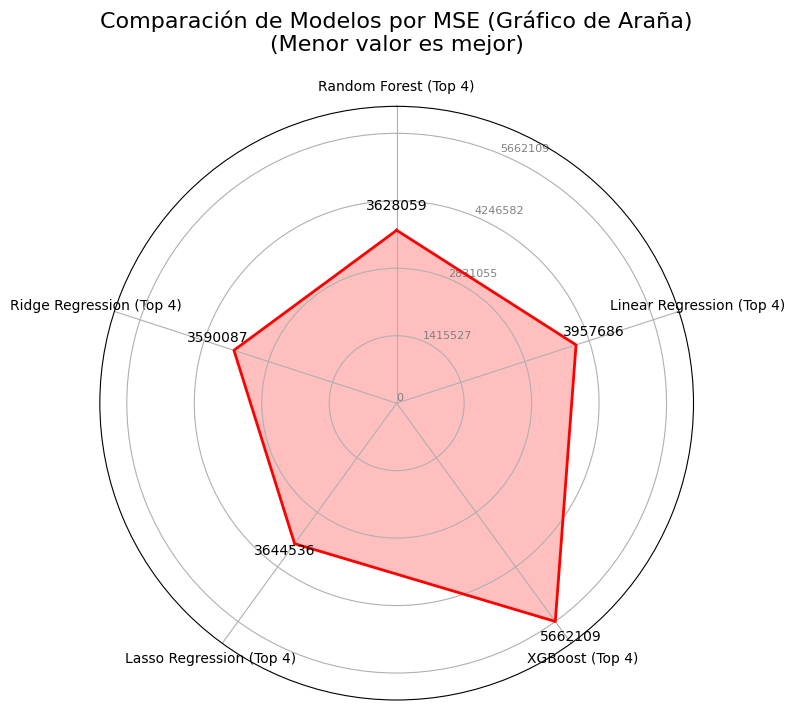

In [ ]:
# Radar Chart for MSE

metrics_to_plot = 'MSE'

models = all_performance_df['Model'].tolist()
scores = all_performance_df[metrics_to_plot].tolist()

num_vars = len(models)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
scores = scores + scores[:1]
angles = angles + angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.plot(angles, scores, color='red', linewidth=2)
ax.fill(angles, scores, color='red', alpha=0.25)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(models)

# Adjust y-axis limits for MSE
max_mse = all_performance_df['MSE'].max()
ax.set_yticks(np.linspace(0, max_mse, 5))
ax.set_yticklabels([f'{x:.0f}' for x in np.linspace(0, max_mse, 5)], color="gray", size=8)
ax.set_ylim(0, max_mse * 1.1) # Add some padding to the max limit

for i, (angle, score) in enumerate(zip(angles[:-1], scores[:-1])):
    ax.text(angle, score * 1.1, f'{score:.0f}', color='black', ha='center', va='bottom', fontsize=10)

plt.title(f'Comparación de Modelos por {metrics_to_plot} (Gráfico de Araña)\n(Menor valor es mejor)', size=16, color='black', y=1.08)
plt.tight_layout()
plt.show()

### Gráfico de Araña para Root Mean Squared Error (RMSE)

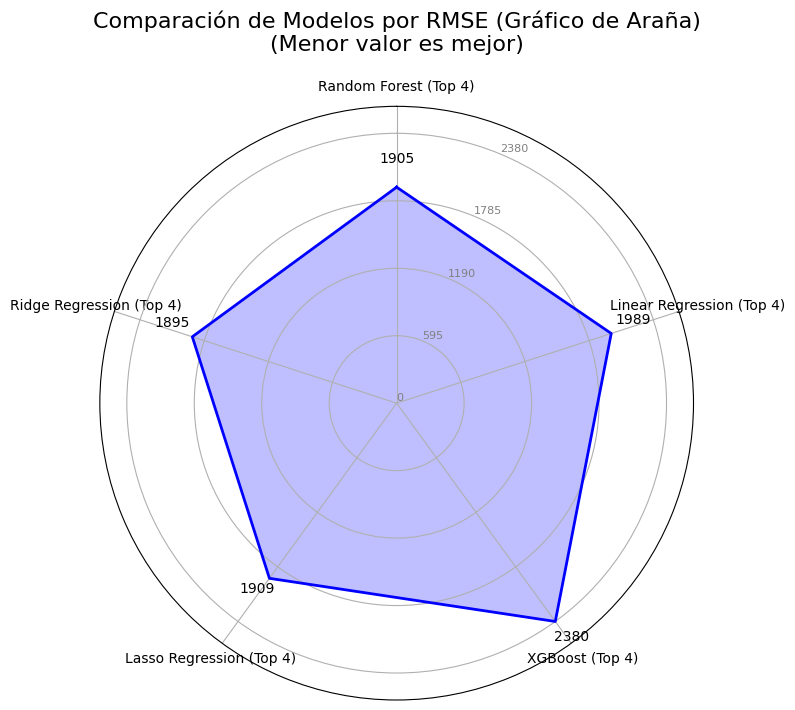

In [ ]:
# Radar Chart for RMSE

metrics_to_plot = 'RMSE'

models = all_performance_df['Model'].tolist()
scores = all_performance_df[metrics_to_plot].tolist()

num_vars = len(models)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
scores = scores + scores[:1]
angles = angles + angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.plot(angles, scores, color='blue', linewidth=2)
ax.fill(angles, scores, color='blue', alpha=0.25)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(models)

# Adjust y-axis limits for RMSE
max_rmse = all_performance_df['RMSE'].max()
ax.set_yticks(np.linspace(0, max_rmse, 5))
ax.set_yticklabels([f'{x:.0f}' for x in np.linspace(0, max_rmse, 5)], color="gray", size=8)
ax.set_ylim(0, max_rmse * 1.1) # Add some padding to the max limit

for i, (angle, score) in enumerate(zip(angles[:-1], scores[:-1])):
    ax.text(angle, score * 1.1, f'{score:.0f}', color='black', ha='center', va='bottom', fontsize=10)

plt.title(f'Comparación de Modelos por {metrics_to_plot} (Gráfico de Araña)\n(Menor valor es mejor)', size=16, color='black', y=1.08)
plt.tight_layout()
plt.show()

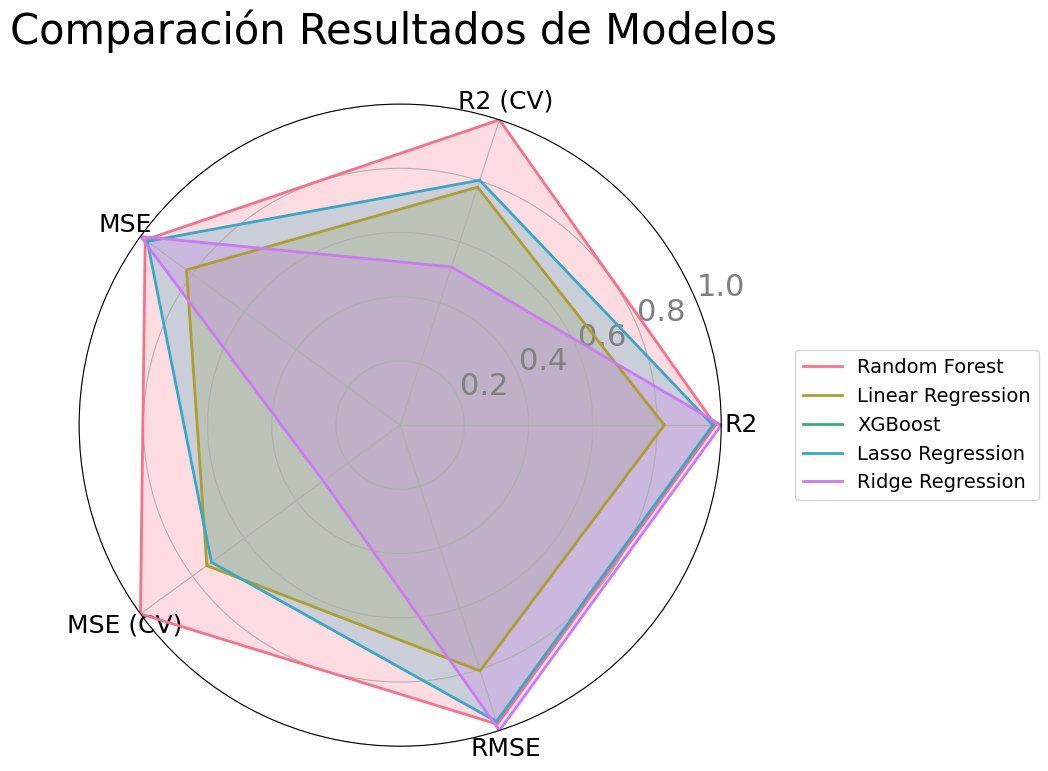

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns # Import seaborn for color palettes

# Ensure all_performance_df is available from previous cells
try:
    all_performance_df
except NameError:
    print("DataFrame 'all_performance_df' not found. Please run previous cells.")
    exit()

# Define the metrics for the radar chart axes
metrics_for_radar = ['R2', 'R2 (CV)', 'MSE', 'MSE (CV)', 'RMSE']

# Create a DataFrame for plotting, selecting only the relevant metrics and models
radar_df = all_performance_df[['Model', 'R-squared', 'R-squared (CV)', 'MSE', 'MSE (CV)', 'RMSE']].copy()
# Rename 'R-squared' column to 'R2' for consistent plotting
radar_df.rename(columns={'R-squared': 'R2', 'R-squared (CV)': 'R2 (CV)'}, inplace=True)

# Remove '(Top 4)' from model names for cleaner labels on the plot
radar_df['Model'] = radar_df['Model'].str.replace(' (Top 4)', '', regex=False)

# Initialize a MinMaxScaler for normalization
scaler = MinMaxScaler()

# Normalize R-squared metrics (higher is better)
for col in ['R2', 'R2 (CV)']:
    # Avoid division by zero if all values are the same
    if radar_df[col].max() == radar_df[col].min():
        radar_df[f'Normalized_{col}'] = 0.5 # Assign a neutral value if no variance
    else:
        radar_df[f'Normalized_{col}'] = scaler.fit_transform(radar_df[[col]])

# Normalize MSE/RMSE metrics (lower is better, so invert after scaling)
for col in ['MSE', 'MSE (CV)', 'RMSE']:
    # Avoid division by zero if all values are the same
    if radar_df[col].max() == radar_df[col].min():
        radar_df[f'Normalized_{col}'] = 0.5 # Assign a neutral value if no variance
    else:
        radar_df[f'Normalized_{col}'] = 1 - scaler.fit_transform(radar_df[[col]])

# Prepare the data for the radar chart
# The number of variables (axes)
num_vars = len(metrics_for_radar)

# Calculate the angle for each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
# Complete the loop for plotting
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# Define a more striking color palette
colors = sns.color_palette('husl', n_colors=len(radar_df['Model'].unique()))

# Iterate through each model and plot its performance
for index, row in radar_df.iterrows():
    model_name = row['Model']
    # Get normalized scores for the current model
    scores = [row[f'Normalized_{metric}'] for metric in metrics_for_radar]
    scores += scores[:1] # Complete the loop for plotting

    ax.plot(angles, scores, linewidth=2, linestyle='solid', label=model_name, color=colors[index])
    ax.fill(angles, scores, alpha=0.25, color=colors[index])

# Set the labels for each axis
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_for_radar, fontsize=18)

# Set y-axis ticks and labels (0 to 1 for normalized scores)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels([f'{x:.1f}' for x in [0.2, 0.4, 0.6, 0.8, 1.0]], color="grey", size=22)
ax.set_ylim(0, 1) # Normalized scale

plt.title('Comparación Resultados de Modelos ', size=30, color='black', y=1.08)
plt.legend(loc='center left', bbox_to_anchor=(1.1, 0.5), fontsize=14) # Moved legend to the right, centered vertically
plt.tight_layout()
plt.show()

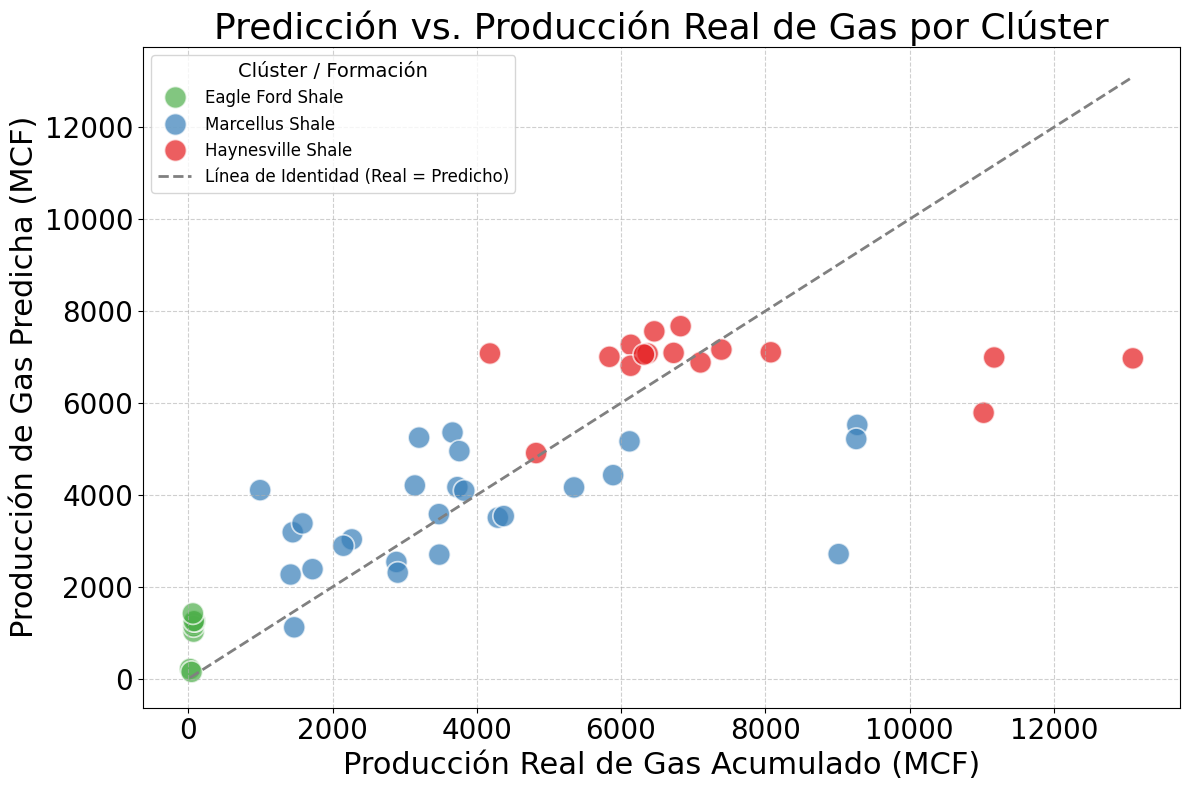

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Asegurarse de que el modelo Ridge (Top 4) y las características estén definidos
try:
    ridge_model_top4
    top_4_features
    pca_df_clusters
    X
    custom_palette # Ensure custom_palette is accessible
except NameError:
    print("Asegúrate de que 'ridge_model_top4', 'top_4_features', 'pca_df_clusters', 'X' y 'custom_palette' estén definidos ejecutando las celdas anteriores.")
    # En un entorno interactivo, podrías pedir al usuario que ejecute celdas.
    # Para este ejemplo, si no están definidos, salimos o manejamos el error.
    exit()

# Hacer predicciones sobre todo el conjunto de datos usando el modelo Ridge
X_full_top4 = X[top_4_features]
predictions = ridge_model_top4.predict(X_full_top4)

# Añadir las predicciones al DataFrame de clusters
pca_df_clusters['Predicted_Gas_Production'] = predictions

# Crear el gráfico de dispersión con líneas de regresión por clúster
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Cumulative Gas Produced after 1 year, MCF', # Valores reales
    y='Predicted_Gas_Production', # Valores predichos
    hue='Formation_Label', # Colorear por clúster (etiqueta de formación)
    data=pca_df_clusters,
    palette=custom_palette, # Usar la paleta de colores personalizada
    s=250, # Tamaño de los puntos
    alpha=0.7, # Transparencia
    edgecolor='w' # Borde blanco para los puntos
)

# Añadir una línea de identidad (y=x) para ver la precisión ideal
min_val = pca_df_clusters[['Cumulative Gas Produced after 1 year, MCF', 'Predicted_Gas_Production']].min().min()
max_val = pca_df_clusters[['Cumulative Gas Produced after 1 year, MCF', 'Predicted_Gas_Production']].max().max()
plt.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--', linewidth=2, label='Línea de Identidad (Real = Predicho)')

plt.title('Predicción vs. Producción Real de Gas por Clúster', fontsize=26) # Título más grande
plt.xlabel('Producción Real de Gas Acumulado (MCF)', fontsize=22) # Eje X más grande
plt.ylabel('Producción de Gas Predicha (MCF)', fontsize=22) # Eje Y más grande
plt.tick_params(axis='both', labelsize=20) # Valores de los ticks más grandes
plt.legend(title='Clúster / Formación', loc='upper left', fontsize=12, title_fontsize=14) # Leyenda dentro y con tamaño de fuente ajustado
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Predicción vs. Real por Clúster (Usando Ridge Regression con Top 4 Features)

**2. Modelos de Clustering**

Con los datos transformados mediante PCA, se aplicó el método del codo, el cual indicó que un número óptimo de grupos para el algoritmo K‑Means era K = 3. Al ejecutar K‑Means con este valor, los datos se agruparon en tres clústeres claramente diferenciados dentro del plano PC1–PC2, evidenciando patrones consistentes entre condiciones de roca y diseño de completamiento. Este resultado fue consistente con la estructura observada en el espacio PCA y respaldó la selección de K = 3 como el número adecuado de clústeres para representar la heterogeneidad del conjunto de pozos.

Posteriormente, se realizó un **análisis de K-Means con K = 5** para las formaciones principales. Los clústeres resultantes se mapearon a sus formaciones dominantes, que incluyen 'HAYNESVILLE_SHALE', 'MARCELLUS', 'EAGLE_FORD' y 'MARCELLUS_UPPER' (que apareció en dos clústeres). La visualización de estos 5 clústeres se ajustó para mostrar la producción de gas en **Miles de Pies Cúbicos (MSCF)** y se asignaron colores específicos a las formaciones ('HAYNESVILLE_SHALE' en rojo, 'MARCELLUS' en azul, 'EAGLE_FORD' en verde y 'MARCELLUS_UPPER' en naranja) para una clara identificación.

También se construyó un dendrograma jerárquico, el cual confirmó la existencia de tres agrupaciones principales dentro del dataset, lo cual validó la estructura inicial de K=3 obtenida con K-Means.

**3. Modelos de Regresión**

Para la etapa predictiva, se dividieron los datos en entrenamiento (80%) y prueba (20%), y se evaluaron distintos modelos utilizando las **cuatro variables más importantes** identificadas previamente (`Bottom Perf (ft)`, `Lateral Length (ft)`, `Porosity`, `Gas Saturation`). Los resultados obtenidos (R² en el conjunto de prueba) y su desempeño en validación cruzada (CV) son:

*   **Ridge Regression:** R² ≈ 0.53, R² (CV) ≈ 0.55
*   **Random Forest:** R² ≈ 0.53, R² (CV) ≈ 0.62
*   **Lasso Regression:** R² ≈ 0.53, R² (CV) ≈ 0.59
*   **Regresión Lineal Múltiple:** R² ≈ 0.49, R² (CV) ≈ 0.59
*   **XGBoost:** R² ≈ 0.27, R² (CV) ≈ 0.47

El modelo **Ridge Regression** y **Random Forest** obtuvieron el mejor desempeño general en el conjunto de prueba (R² ≈ 0.53), siendo **Ridge** ligeramente superior. En términos de la validación cruzada, **Random Forest** mostró un rendimiento promedio más alto (R² (CV) ≈ 0.62). **Lasso Regression** ofreció un rendimiento muy competitivo y estable. La **Regresión Lineal Múltiple** sirvió como modelo base con un desempeño moderado. Finalmente, **XGBoost** presentó el rendimiento más bajo entre los modelos evaluados para este conjunto reducido de características.

Estos resultados sugieren que, incluso con un número reducido de características, modelos como Ridge y Random Forest son capaces de mantener una capacidad predictiva razonable.